# Fundamental Diagnostics Map

Compact shot-grid maps for quick plasma-condition comparison across many cached shots.

## Configuration

This notebook only reads cached data from `../local/`. It does not download diagnostics.

In [1]:
from pathlib import Path

from lhd_data.plotting import FundamentalSignalSpec, plot_fundamental_map

CACHE_DIR = Path("../local/lhd_data")
if not CACHE_DIR.exists():
    CACHE_DIR = Path("../local/bh-molecule")

SHOTS = range(193772, 193820)

## Default Compact Map

Rows inside each shot panel are the default compact fundamentals: NBI power, `ne`, `Te`, and H-alpha. Each row is robust-scaled globally across shots so colors are comparable.

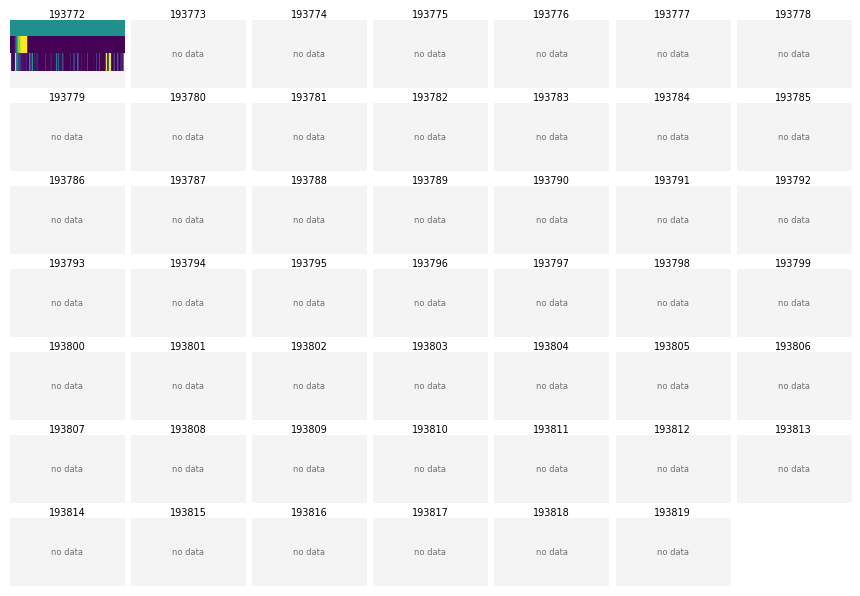

In [3]:
fig, axes = plot_fundamental_map(
    SHOTS,
    cache_dir=CACHE_DIR,
    columns=7,
    tmin=3.2,
    tmax=9.0,
    time_bins=96,
    scale="global",
    dark=False,
)

## Dark Background Variant

The same plot can be rendered for dark poster backgrounds.

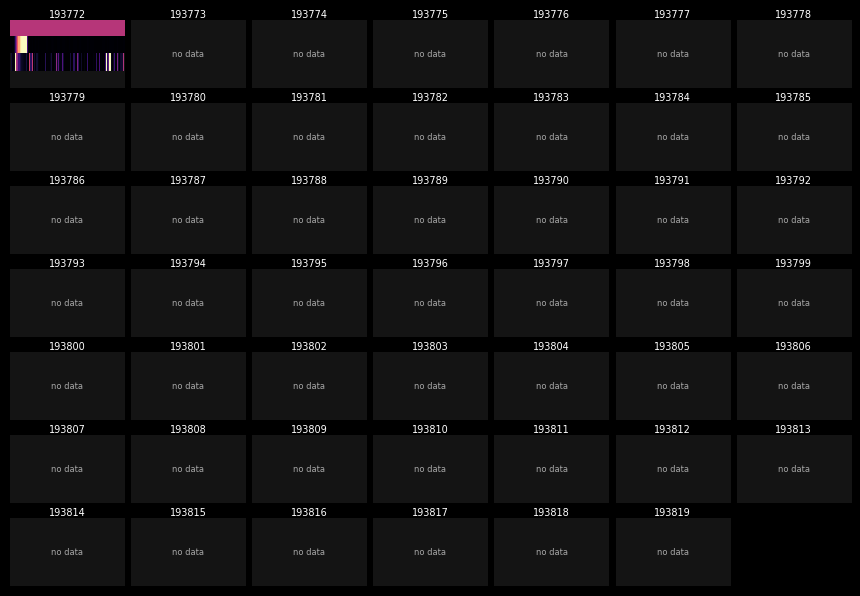

In [4]:
fig_dark, axes_dark = plot_fundamental_map(
    SHOTS,
    cache_dir=CACHE_DIR,
    columns=7,
    tmin=3.2,
    tmax=9.0,
    time_bins=96,
    scale="global",
    dark=True,
)

## Config-Shaped Custom Signals

The plotter accepts explicit signal specs so a future TOML/CLI layer can translate configuration into plotting rows without changing the plotting logic.

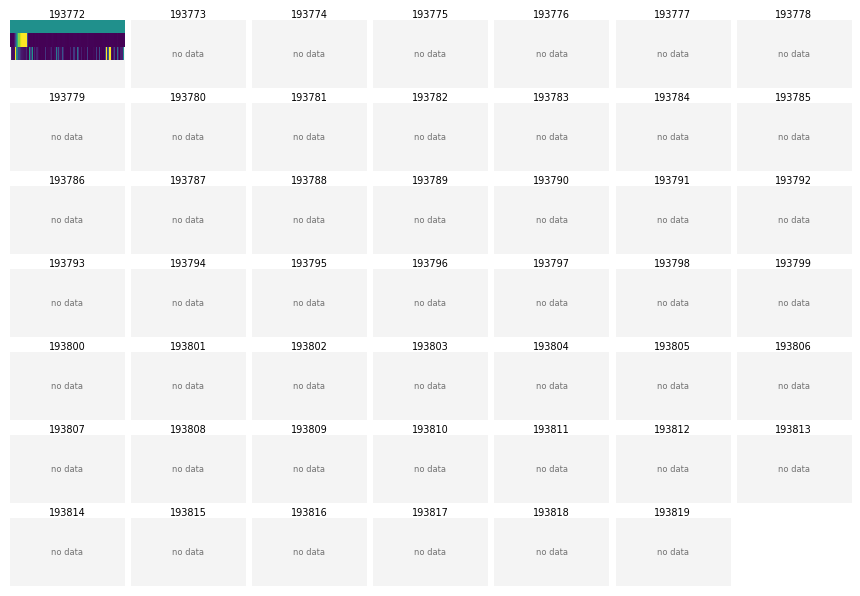

In [5]:
signals = [
    "nbi",
    "ne",
    "te",
    "halpha",
    FundamentalSignalSpec("wp", diagnostic="wp", variable="Wp", kind="stored_power"),
]

fig_custom, axes_custom = plot_fundamental_map(
    SHOTS,
    cache_dir=CACHE_DIR,
    signals=signals,
    columns=7,
    tmin=3.2,
    tmax=9.0,
    time_bins=96,
)